# Unified Dataset EDA

## Goals
- Understand dataset shape, schema, and missingness
- Describe target (fraud flag) prevalence
- Profile providers by year and state
- Specialty profiling:
  - Total samples per specialty
  - Fraud flags overall
  - Fraud vs non-fraud counts per specialty
- Clustering
  - PCA see if the clusters show that there are only a few columns that contribute to a majority of the variance

In [1]:
#############################################################################==
# IMPORTS AND CONFIGURATION
#############################################################################==
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install umap-learn

In [2]:
import warnings
# Configure warnings display
warnings.filterwarnings("ignore")

# Configure pandas display options
pd.set_option("display.max_columns", 200)
# Configure pandas float formatting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
# =============================================================================
# PLOT TEMPLATE — Presentation-Quality Style
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# 1. COLORBLIND-FRIENDLY PALETTE (Wong 2011, Nature Methods)
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# 2. FONT DETECTION
def list_fonts(filter_text=None):
    names = sorted({f.name for f in fm.fontManager.ttflist})
    if filter_text:
        names = [n for n in names if filter_text.lower() in n.lower()]
    print(f"Found {len(names)} font{'s' if len(names) != 1 else ''}:\n")
    for n in names:
        print(f"  \u2022 {n}")
    return names

_FONT_PREFERENCES = [
    "Arial", "Helvetica", "Helvetica Neue", "Calibri",
    "Verdana", "Segoe UI", "Liberation Sans", "DejaVu Sans",
]

def _find_best_font():
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")

FONT_SIZE_TITLE  = 35
FONT_SIZE_LABEL  = 35
FONT_SIZE_TICK   = 35
FONT_SIZE_LEGEND = 35
FONT_SIZE_ANNOT  = 35

# 3. APPLY GLOBAL STYLE
def apply_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size": FONT_SIZE_ANNOT,
        "axes.titlesize": FONT_SIZE_TITLE, "axes.titleweight": "bold",
        "axes.labelsize": FONT_SIZE_LABEL, "axes.labelweight": "bold",
        "axes.prop_cycle": mpl.cycler(color=CB_PALETTE),
        "axes.linewidth": 1.5, "axes.edgecolor": "#000000",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "axes.axisbelow": True,
        "xtick.labelsize": FONT_SIZE_TICK, "ytick.labelsize": FONT_SIZE_TICK,
        "xtick.major.width": 1.5, "ytick.major.width": 1.5,
        "xtick.major.size": 6, "ytick.major.size": 6,
        "xtick.direction": "out", "ytick.direction": "out",
        "grid.color": "#dbdbdb", "grid.linewidth": 0.8, "grid.alpha": 1.0,
        "legend.fontsize": FONT_SIZE_LEGEND, "legend.frameon": True,
        "legend.framealpha": 0.9, "legend.edgecolor": "#999999",
        "legend.fancybox": True, "legend.shadow": False, "legend.loc": "best",
        "lines.linewidth": 2.5, "lines.markersize": 10,
        "figure.figsize": (12, 7), "figure.dpi": 100,
        "figure.facecolor": "white",
        "figure.titlesize": FONT_SIZE_TITLE, "figure.titleweight": "bold",
        "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.facecolor": "white",
    })
    sns.set_theme(style="whitegrid", font=FONT_FAMILY, font_scale=1.4, rc=mpl.rcParams)
    sns.set_palette(CB_PALETTE)
    mpl.rcParams.update({
        "axes.titlesize": FONT_SIZE_TITLE, "axes.titleweight": "bold",
        "axes.labelweight": "bold", "axes.edgecolor": "#000000",
        "axes.spines.top": False, "axes.spines.right": False,
        "figure.titlesize": FONT_SIZE_TITLE, "figure.titleweight": "bold",
        "grid.color": "#dbdbdb", "grid.alpha": 1.0,
    })

apply_style()

# 4. HELPER FUNCTIONS
def add_legend(ax=None, title=None, **kwargs):
    ax = ax or plt.gca()
    defaults = dict(fontsize=FONT_SIZE_LEGEND, frameon=True, framealpha=0.9,
                    edgecolor="#999999", loc="best")
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend

def get_colors(n=None):
    if n is None:
        return CB_PALETTE.copy()
    return CB_PALETTE[:n]

def finalize(fig=None, tight=True):
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()

print("Plot template applied — presentation-quality style active.")

Font: Liberation Sans
Plot template applied — presentation-quality style active.


In [4]:
#############################################################################==
# DATA LOADING
#############################################################################==
# Load dataset with conservative memory handling
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/unified_dataset.csv")

# Print basic shape
print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
# Print memory usage
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:,.2f} MB")


Dataset Shape: 140,827 rows x 216 columns
Memory Usage: 233.93 MB


In [5]:
# Display a random sample of rows
display(df.sample(5, random_state=42))


,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplrs_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_clms_max,cnt_tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90,accessories_for_oxygen_delivery_devices,breathing_aids,hospital_beds_and_associated_supplies,humidifiers_and_nebulizers_with_related_equipment,infusion_pumps_and_supplies,inhalation_solutions,other_supplies_including_diabetes_supplies_and_contraceptives,oxygen_delivery_systems_and_related_supplies,pharmacy_supply_and_dispensing_fees,wheelchairs_components_and_accessories,bene_age_lt_65_cnt,bene_age_gt_84_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre,n_manufacturing_entities,total_payment,third_party_equals_covered_recipient_indicator,covered_biological,covered_device,covered_drug,covered_medical supply,non-covered_device,non-covered_drug,non-covered_medical supply,is_weekend_payment,is_q4_payment,dme_glucose_monitors,dme_urological_supplies,dme_surgical_dressings,dme_positive_airway,dme_lower_limb_orthotics,dme_parenteral_nutrition,dme_ventilators,dme_diabetes_supplies_and_contraceptives,dme_oxygen_accessories,dme_oxygen_equipment,dme_humidifiers_and_nebulizers,dme_infusion_pumps,dme_breathing_aids,dme_replacement_batteries,dme_tapes_and_medical_supplies,n_cities,n_countries,form_count_cash_or_cash_equivalent,...,nature_count_entertainment,nature_count_faculty_or_speaker,nature_count_other_services,nature_sum_acquisition,nature_sum_consulting,nature_sum_debt_forgiveness,nature_sum_entertainment,nature_sum_faculty_or_speaker,nature_sum_food_and_beverage,nature_sum_other_services,nature_sum_ownership_or_investment,n_third_party_entities,total_invested_usd,total_value_of_interest,immediate_family_member,physician_covered_recipient,specialty_type,specialty,specialty_lvl1_Agencies,specialty_lvl1_Allopathic & Osteopathic Physicians,specialty_lvl1_Behavioral Health & Social Service Providers,specialty_lvl1_Dental Providers,specialty_lvl1_Eye and Vision Services Providers,specialty_lvl1_Nursing Service Providers,specialty_lvl1_Other Service Providers,specialty_lvl1_Pharmacy Service Providers,specialty_lvl1_Physician Assistants & Advanced Practice Nursing Providers,specialty_lvl1_Podiatric Medicine & Surgery Service Providers,specialty_lvl1_Student,active_medicaid_provider_flag,submitted_charge_per_bene_missing_flag,submitted_charge_per_bene_num_missing_flag,submitted_charge_per_bene_den_missing_flag,submitted_charge_per_bene_den_zero_flag,submitted_to_standardized_ratio_missing_flag,submitted_to_standardized_ratio_num_missing_flag,submitted_to_standardized_ratio_den_missing_flag,claims_per_bene_missing_flag,claims_per_bene_num_missing_flag,claims_p

In [6]:
#############################################################################==
# BASIC CLEANUP AND TYPE COERCION
#############################################################################==
# Drop unnamed index column if present
if "Unnamed: 0" in df.columns:
    # Remove redundant index column
    df = df.drop(columns=["Unnamed: 0"])

# Coerce key identifier columns
# Convert npi to numeric where possible
df["npi"] = pd.to_numeric(df["npi"], errors="coerce")
# Convert year to integer where possible
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
# Convert target to integer where possible
df["target"] = pd.to_numeric(df["target"], errors="coerce").astype("Int64")

# Normalize state column if present
if "rfrg_prvdr_state_abrvtn" in df.columns:
    # Cast state to string and strip whitespace
    df["rfrg_prvdr_state_abrvtn"] = df["rfrg_prvdr_state_abrvtn"].astype(str).str.strip()
    # Replace placeholder strings with missing
    df.loc[df["rfrg_prvdr_state_abrvtn"].isin(["nan", "None", "NULL", ""]), "rfrg_prvdr_state_abrvtn"] = np.nan

# Print updated shape
print(f"Post-clean Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Post-clean Shape: 140,827 rows x 216 columns


,missing_pct,missing_cnt
accessories_for_oxygen_delivery_devices,0.0000,0
active_medicaid_provider_flag,0.0000,0
avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max,0.0000,0
avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,0.0000,0
avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,0.0000,0
avg_suplr_mdcr_pymt_amt_max,0.0000,0
avg_suplr_mdcr_pymt_amt_min,0.0000,0
avg_suplr_mdcr_pymt_amt_sum,0.0000,0
avg_suplr_sbmtd_chrg_max_outlier,0.0000,0
avg_suplr_sbmtd_chrg_max_outlier_by_type,0.0000,0


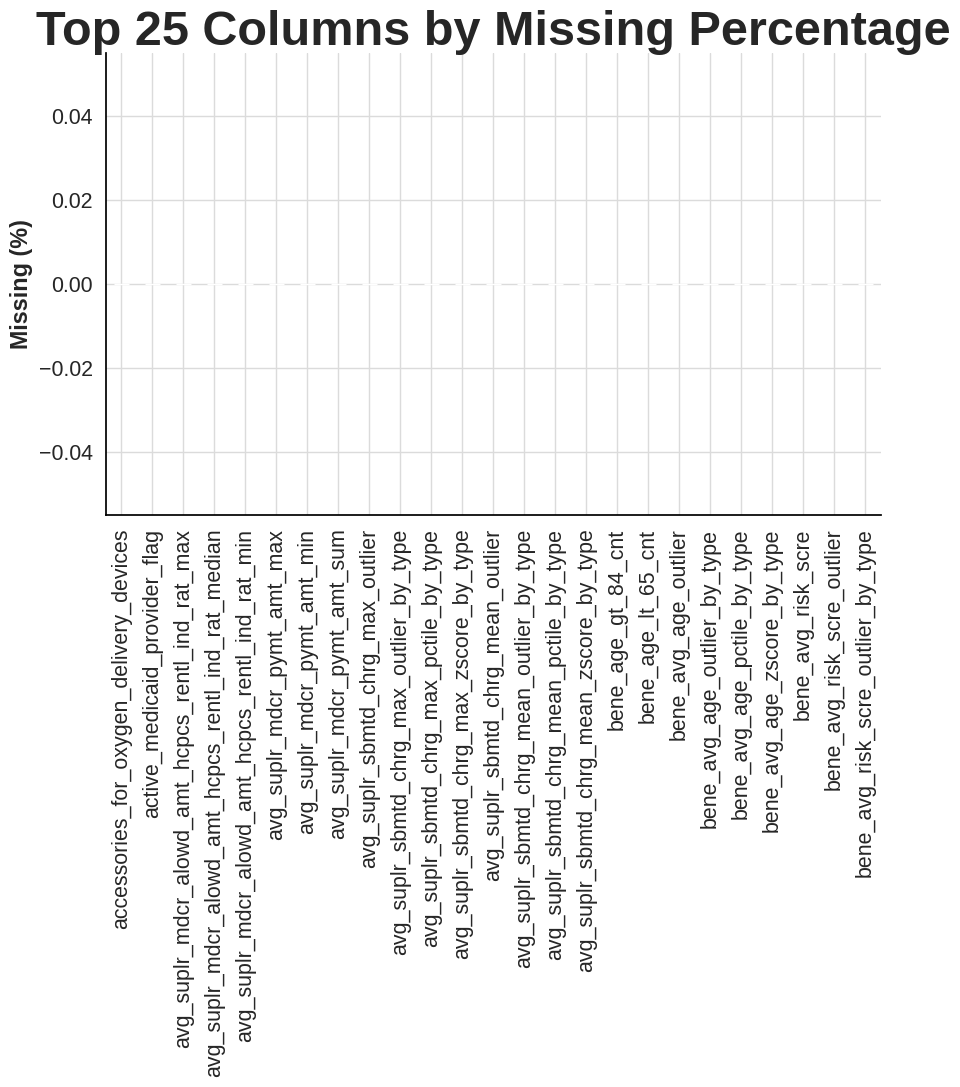

In [7]:
#############################################################################==
# MISSINGNESS OVERVIEW
#############################################################################==
# Compute missingness per column
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
# Build missingness table
missing_tbl = pd.DataFrame({"missing_pct": missing_pct, "missing_cnt": df.isna().sum()})
# Display top columns by missing percentage
display(missing_tbl.head(25))

# Plot missingness for top 25 columns
# Create figure
plt.figure(figsize=(10, 6))
# Plot bar chart of missing percentages
missing_tbl.head(25)["missing_pct"].plot(kind="bar")
# Add title
plt.title("Top 25 Columns by Missing Percentage")
# Add y-axis label
plt.ylabel("Missing (%)")
# Improve layout
plt.tight_layout()
# Render plot
plt.show()


,count,proportion
target,,
0,140771,0.9996
1,56,0.0004


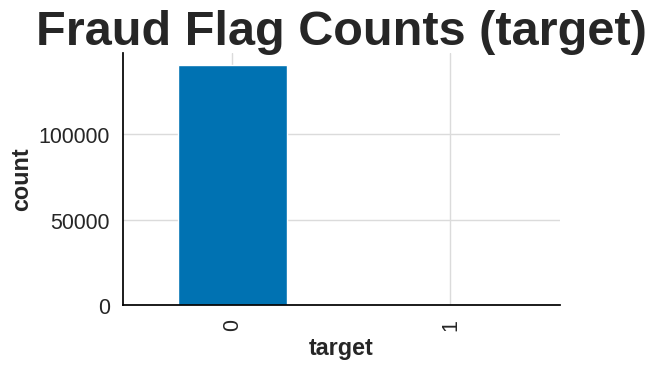

Overall fraud flags (target=1): 56
Overall non-fraud (target=0): 140,771


In [8]:
#############################################################################==
# TARGET (FRAUD FLAG) OVERVIEW
#############################################################################==
# Validate target existence
assert "target" in df.columns, "Expected 'target' column not found"

# Compute target counts
target_counts = df["target"].value_counts(dropna=False).sort_index()
# Compute target proportions
target_props = df["target"].value_counts(normalize=True, dropna=False).sort_index()

# Display counts and proportions
display(pd.DataFrame({"count": target_counts, "proportion": target_props}))

# Plot target distribution
# Create figure
plt.figure(figsize=(6, 4))
# Plot bar chart for target counts
target_counts.plot(kind="bar")
# Add title
plt.title("Fraud Flag Counts (target)")
# Add x-axis label
plt.xlabel("target")
# Add y-axis label
plt.ylabel("count")
# Improve layout
plt.tight_layout()
# Render plot
plt.show()

# Store overall fraud counts for later sections
overall_targets = int((df["target"] == 1).sum())
overall_nontargets = int((df["target"] == 0).sum())
print(f"Overall fraud flags (target=1): {overall_targets:,}")
print(f"Overall non-fraud (target=0): {overall_nontargets:,}")


year
2021    46926
2022    46755
2023    47146
Name: count, dtype: Int64

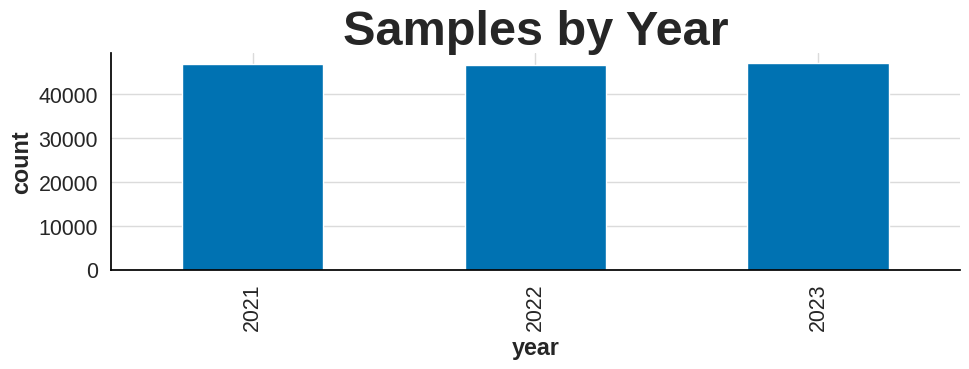

rfrg_prvdr_state_abrvtn
IL    35588
TN    21765
MO    18118
KY    15878
OK    11929
IA    10770
AR    10139
KS     9641
NE     6999
Name: count, dtype: int64

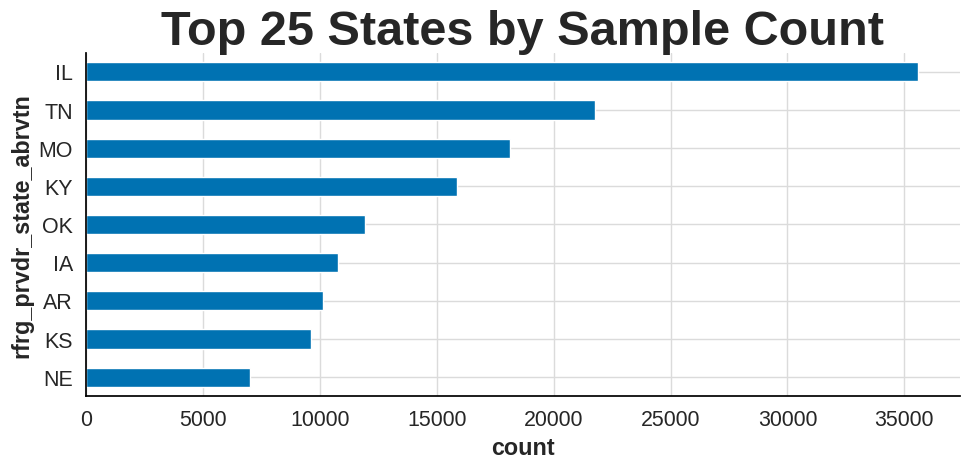

In [9]:
#############################################################################==
# YEAR AND STATE DISTRIBUTIONS
#############################################################################==
# Plot distribution of years
if "year" in df.columns:
    # Compute year counts
    year_counts = df["year"].value_counts(dropna=False).sort_index()
    # Display year counts
    display(year_counts)

    # Create figure
    plt.figure(figsize=(10, 4))
    # Plot year counts
    year_counts.plot(kind="bar")
    # Add title
    plt.title("Samples by Year")
    # Add x-axis label
    plt.xlabel("year")
    # Add y-axis label
    plt.ylabel("count")
    # Improve layout
    plt.tight_layout()
    # Render plot
    plt.show()

# Plot distribution of states
if "rfrg_prvdr_state_abrvtn" in df.columns:
    # Compute state counts
    state_counts = df["rfrg_prvdr_state_abrvtn"].value_counts(dropna=False).head(25)
    # Display top states
    display(state_counts)

    # Create figure
    plt.figure(figsize=(10, 5))
    # Plot top 25 states
    state_counts.sort_values().plot(kind="barh")
    # Add title
    plt.title("Top 25 States by Sample Count")
    # Add x-axis label
    plt.xlabel("count")
    # Improve layout
    plt.tight_layout()
    # Render plot
    plt.show()


,count,mean,std,min,1%,5%,50%,95%,99%,max
year,"140,827.0000","2,022.0016",0.8173,"2,021.0000","2,021.0000","2,021.0000","2,022.0000","2,023.0000","2,023.0000","2,023.0000"
target,"140,827.0000",0.0004,0.0199,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
avg_suplr_mdcr_pymt_amt_sum,"140,827.0000",338.3833,737.2401,0.0000,1.5567,5.6337,137.5431,"1,293.4625","2,474.0381","94,737.9624"
tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,"140,827.0000",0.0794,6.8689,-11.2430,-5.4778,-3.7727,-0.6894,4.6299,27.6474,288.2010
tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,"140,827.0000",-0.2152,0.4528,-2.2346,-0.7291,-0.5642,-0.3235,0.4544,1.5973,24.9733
...,...,...,...,...,...,...,...,...,...,...
claims_per_bene_zscore_by_type,"140,827.0000",0.0000,1.0000,-2.1179,-1.6569,-1.2974,-0.2062,1.7863,3.4467,21.5558
services_per_bene_zscore_by_type,"140,827.0000",0.0000,1.0000,-0.8838,-0.3789,-0.3742,-0.2511,1.4506,4.3637,45.0866
benes_per_supplier_zscore_by_type,"140,827.0000",-0.0000,1.0000,-1.8416,-0.8192,-0.5921,-0.0940,0.5782,2.6841,173.5329
elderly_patient_concentration,"140,827.0000",0.0099,0.0650,0.0000,0.0000,0.0000,0.0000,0.0254,0.2830,3.8000


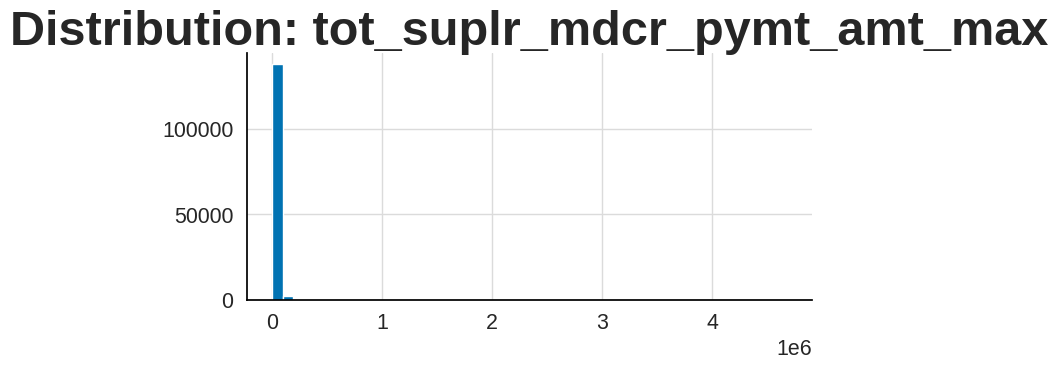

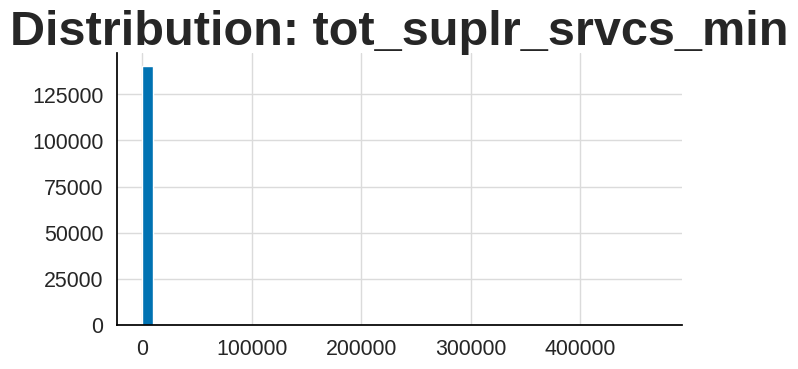

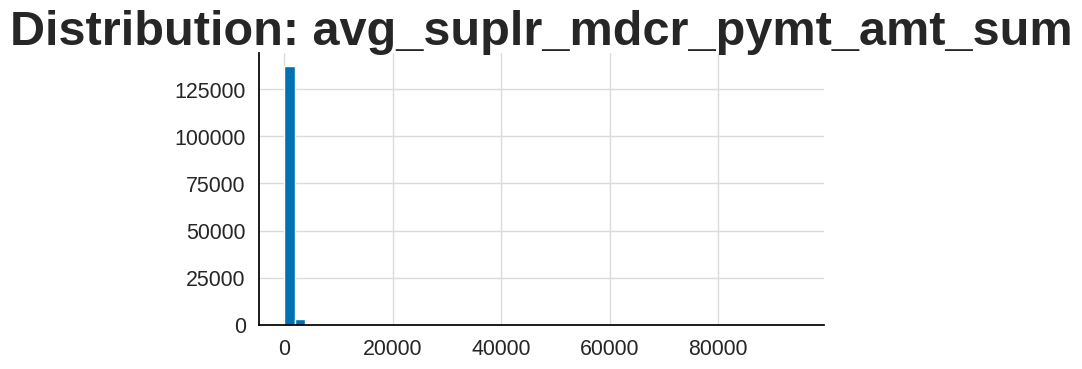

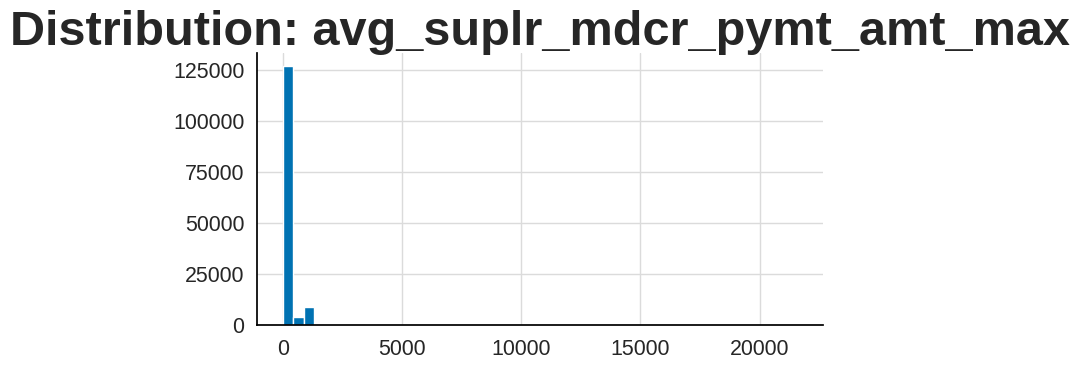

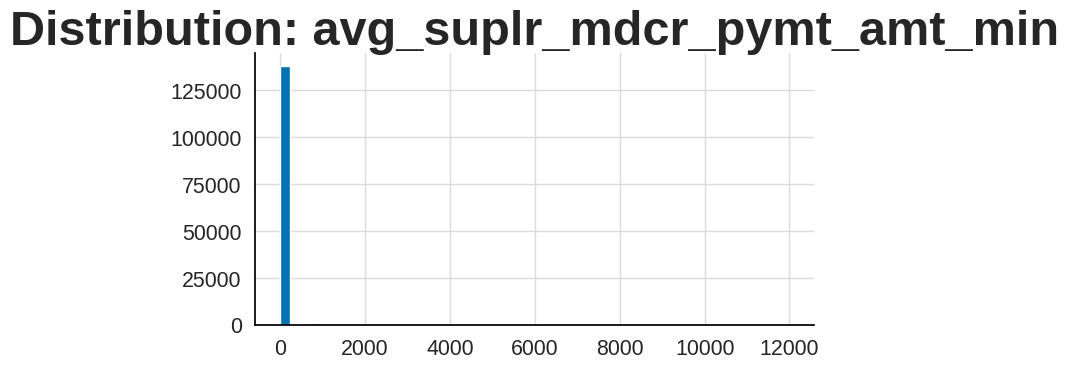

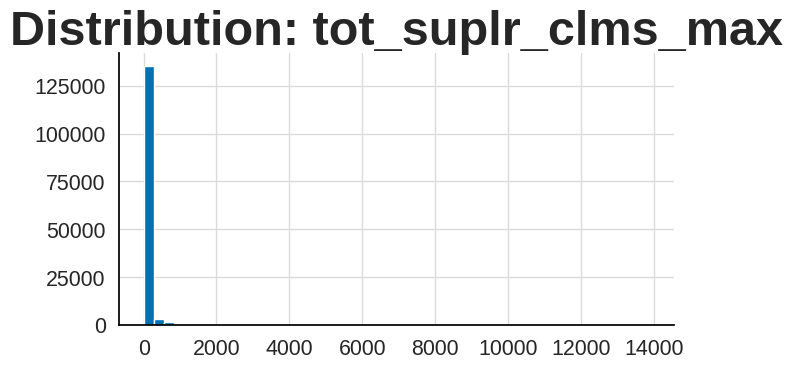

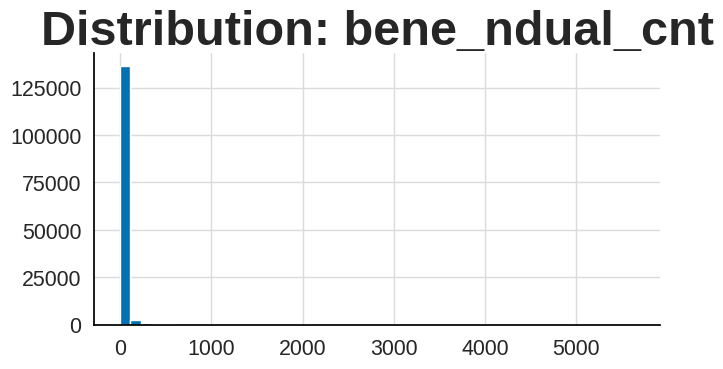

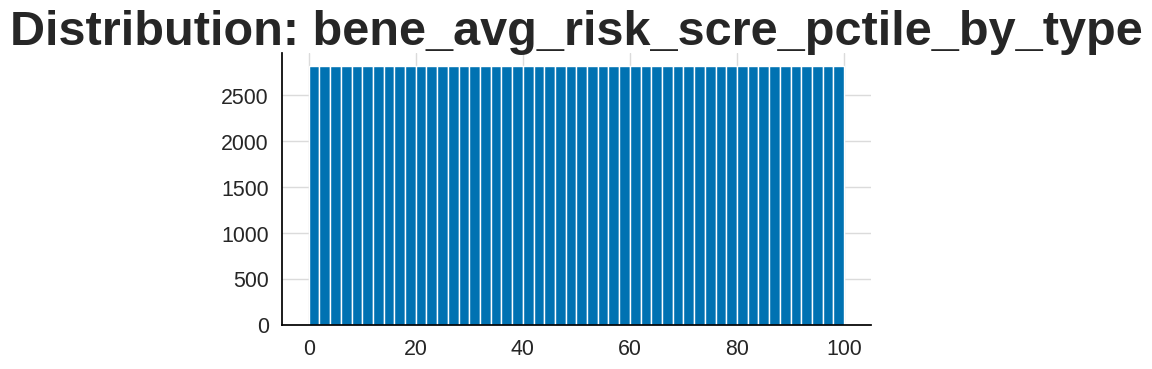

In [10]:
#############################################################################==
# NUMERIC FEATURE SUMMARY
#############################################################################==
# Identify numeric columns
numeric_cols = df.select_dtypes(include=["number", "Int64", "float64", "int64"]).columns.tolist()

# Exclude high-cardinality identifiers from distribution charts
id_like = {"npi"}
# Remove identifiers if present
numeric_cols_for_stats = [c for c in numeric_cols if c not in id_like]

# Display summary statistics
display(df[numeric_cols_for_stats].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

# Select a small set of numeric columns for plots
candidate_keywords = ["pymt", "pymt_amt", "alowd", "sbmtd", "stdzd", "bene", "srvcs", "clms"]
candidate_cols = [c for c in numeric_cols_for_stats if any(k in c.lower() for k in candidate_keywords)]

# Keep up to 8 candidates with highest variance
if len(candidate_cols) > 0:
    # Compute variances
    variances = df[candidate_cols].var(numeric_only=True).sort_values(ascending=False)
    # Select top columns by variance
    plot_cols = variances.head(8).index.tolist()
else:
    # Fallback to first few numeric columns
    plot_cols = numeric_cols_for_stats[:8]

# Plot distributions for selected numeric columns
for col in plot_cols:
    # Create figure
    plt.figure(figsize=(7, 4))
    # Plot histogram with KDE
    plt.hist(df[col].dropna(), bins=50)
    # Add title
    plt.title(f"Distribution: {col}")
    # Improve layout
    plt.tight_layout()
    # Render plot
    plt.show()


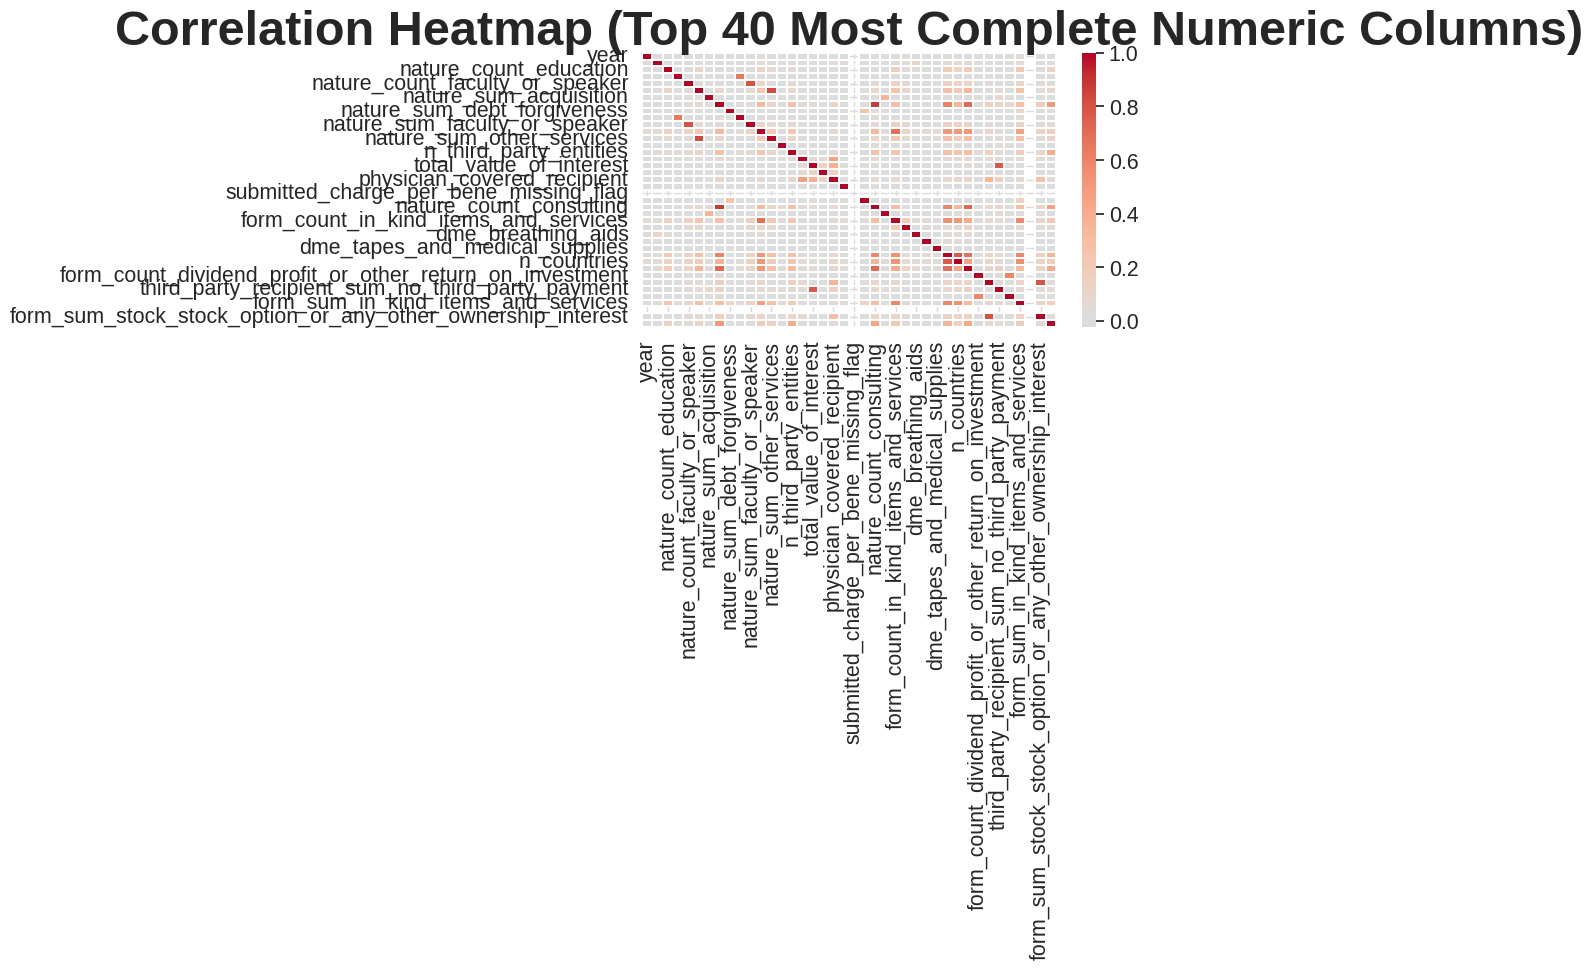

active_medicaid_provider_flag                      -0.0086
year                                               -0.0035
dme_breathing_aids                                 -0.0014
n_countries                                        -0.0012
nature_count_education                             -0.0007
nature_count_debt_forgiveness                      -0.0005
nature_count_entertainment                         -0.0005
nature_count_consulting                            -0.0004
nature_sum_consulting                              -0.0004
nature_sum_entertainment                           -0.0003
dme_tapes_and_medical_supplies                     -0.0003
physician_covered_recipient                        -0.0003
n_cities                                           -0.0003
nature_count_acquisition                           -0.0003
third_party_recipient_sum_no_third_party_payment   -0.0002
Name: target, dtype: float64

immediate_family_member                  -0.0001
nature_sum_faculty_or_speaker             0.0003
third_party_recipient_count_entity        0.0006
form_sum_in_kind_items_and_services       0.0006
nature_sum_other_services                 0.0008
n_third_party_entities                    0.0018
nature_count_faculty_or_speaker           0.0018
nature_count_other_services               0.0022
nature_sum_food_and_beverage              0.0039
avg_suplr_mdcr_pymt_amt_sum               0.0070
form_count_cash_or_cash_equivalent        0.0079
form_count_in_kind_items_and_services     0.0099
dme_infusion_pumps                        0.0138
submitted_charge_per_bene_missing_flag       NaN
form_sum_stock                               NaN
Name: target, dtype: float64

In [11]:
#############################################################################==
# CORRELATION SNAPSHOT (NUMERIC FEATURES)
#############################################################################==
# Filter numeric columns for correlation; cap to avoid oversized plots
corr_cols = numeric_cols_for_stats.copy()

# Drop target from feature correlation view if present
if "target" in corr_cols:
    # Remove target from correlation input
    corr_cols = [c for c in corr_cols if c != "target"]

# Subsample to top 40 most complete numeric columns
# Compute non-null counts
non_null_counts = df[corr_cols].notna().sum().sort_values(ascending=False)
# Select top columns
corr_cols_small = non_null_counts.head(40).index.tolist()

# Compute correlation matrix
corr_mat = df[corr_cols_small].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap (Top 40 Most Complete Numeric Columns)")
plt.tight_layout()
plt.show()

# Show features most correlated with target if target exists
if "target" in df.columns:
    # Compute correlations with target
    target_corr = df[corr_cols_small + ["target"]].corr()["target"].drop("target").sort_values()
    # Display strongest negative correlations
    display(target_corr.head(15))
    # Display strongest positive correlations
    display(target_corr.tail(15))


,unique_providers
specialty_clean,
Nurse Practitioner,15210
Family Practice,12563
Internal Medicine,10325
Physician Assistant,4341
Hospitalist,2341
Orthopedic Surgery,2060
Pulmonary Disease,1480
Urology,1144
General Surgery,1120


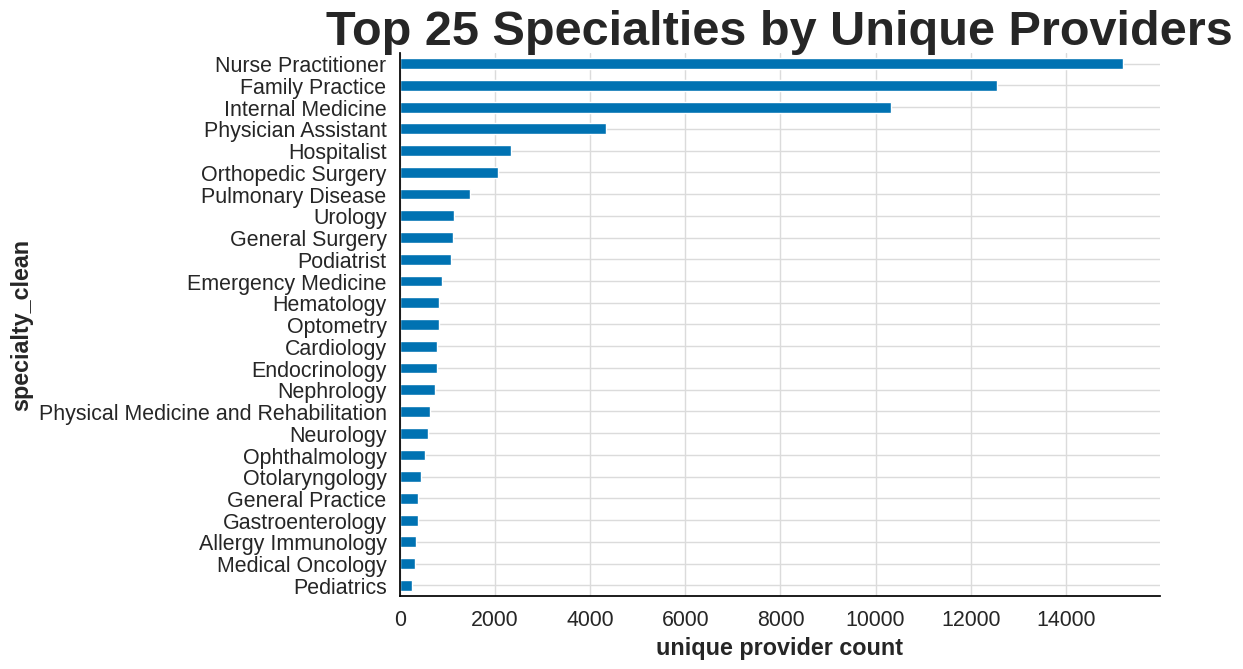

,specialty_clean,total_providers,targets,nontargets,fraud_rate
0,Family Practice,12563,9,12554,0.0007
1,Internal Medicine,10325,8,10317,0.0008
2,Nurse Practitioner,15210,2,15208,0.0001
3,Endocrinology,775,2,773,0.0026
4,Hospitalist,2341,1,2340,0.0004
5,Cardiology,785,1,784,0.0013
6,General Practice,393,1,392,0.0025
7,Physician Assistant,4341,0,4341,0.0000
8,Orthopedic Surgery,2060,0,2060,0.0000
9,Pulmonary Disease,1480,0,1480,0.0000


,specialty_clean,total_providers,targets,nontargets,fraud_rate
3,Endocrinology,775,2,773,0.0026
6,General Practice,393,1,392,0.0025
5,Cardiology,785,1,784,0.0013
1,Internal Medicine,10325,8,10317,0.0008
0,Family Practice,12563,9,12554,0.0007
4,Hospitalist,2341,1,2340,0.0004
2,Nurse Practitioner,15210,2,15208,0.0001
38,Thoracic Surgery,109,0,109,0.0000
30,Geriatric Medicine,190,0,190,0.0000
31,Colorectal Surgery,173,0,173,0.0000


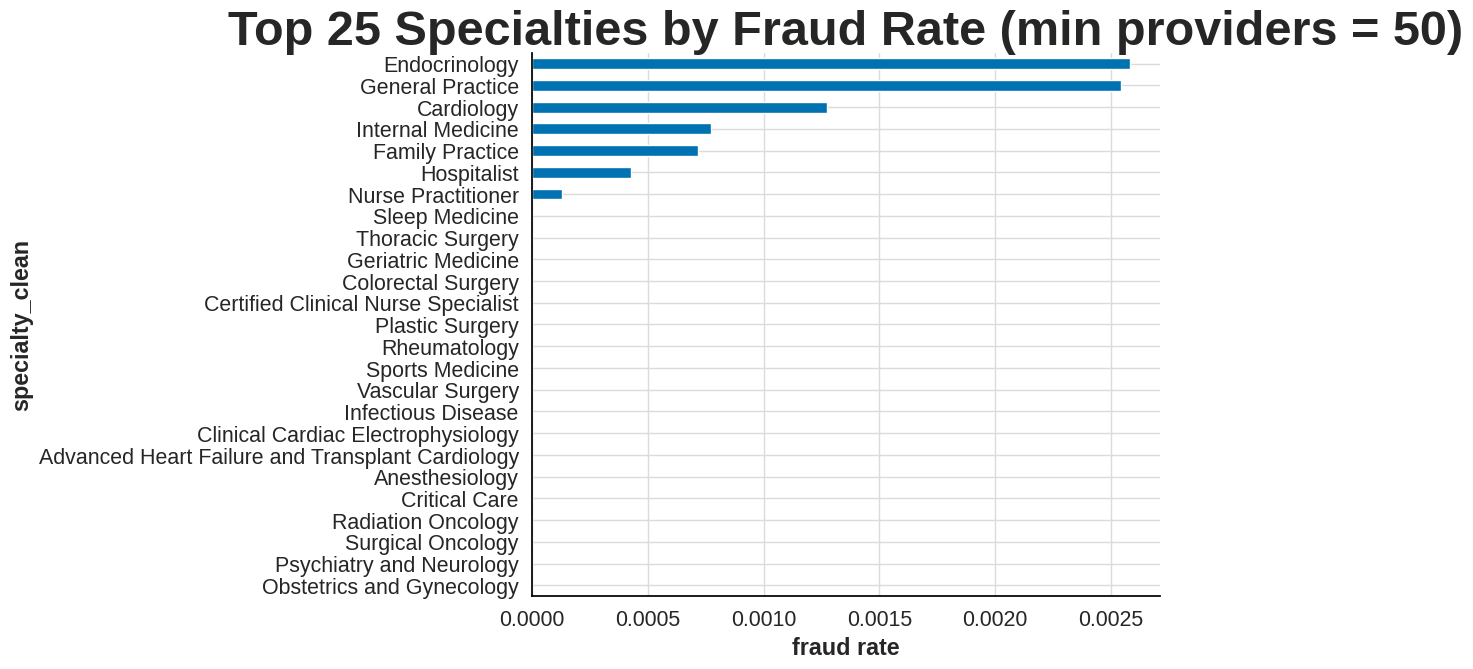

In [37]:
#############################################################################==
# SPECIALTY ANALYSIS
#############################################################################==

# CUSTOMIZE: set the provider identifier column
PROVIDER_ID_COL = "npi"

# Ensure specialty is treated as a clean categorical-like field
# Create a standardized specialty series with missing handled
specialty_clean = (
    df["specialty"]
    .astype("str")
    .fillna("UNKNOWN")
    .str.strip()
    .replace({"": "UNKNOWN"})
)

# Write cleaned specialty back to the dataframe for consistent grouping
df["specialty_clean"] = specialty_clean

# Summarize unique providers per specialty
specialty_total_tbl = (
    df.groupby("specialty_clean")
      .agg(unique_providers=(PROVIDER_ID_COL, "nunique"))
      .sort_values("unique_providers", ascending=False)
)

# Display top specialties by unique providers
display(specialty_total_tbl.head(25))

# Plot top 25 specialties by unique providers
plt.figure(figsize=(12, 7))
specialty_total_tbl["unique_providers"].head(25).sort_values().plot(kind="barh")
plt.title("Top 25 Specialties by Unique Providers")
plt.xlabel("unique provider count")
plt.tight_layout()
plt.show()

# Create a fraud indicator from the target field
is_fraud = df["target"] == 1

# Create a non-fraud indicator from the target field
is_nonfraud = df["target"] == 0

# Aggregate specialty metrics with unique provider counts
specialty_fraud_tbl = (
    df.groupby("specialty_clean")
      .agg(
          total_providers=(PROVIDER_ID_COL, "nunique"),
          targets=(PROVIDER_ID_COL, lambda x: x[df.loc[x.index, "target"] == 1].nunique()),
          nontargets=(PROVIDER_ID_COL, lambda x: x[df.loc[x.index, "target"] == 0].nunique()),
      )
      .sort_values(["targets", "total_providers"], ascending=False)
      .reset_index()
)

# Compute fraud rate with safe division
specialty_fraud_tbl["fraud_rate"] = np.where(
    specialty_fraud_tbl["total_providers"] > 0,
    specialty_fraud_tbl["targets"] / specialty_fraud_tbl["total_providers"],
    np.nan,
)

# Display top specialties by unique fraud provider counts
display(specialty_fraud_tbl.head(25))


# Plot top 25 specialties by fraud rate
# CUSTOMIZE: adjust stability threshold for fraud-rate plots
MIN_PROVIDERS_FOR_RATE = 50

# Filter table for stable rate estimates
rate_tbl = specialty_fraud_tbl[specialty_fraud_tbl["total_providers"] >= MIN_PROVIDERS_FOR_RATE].copy()

# Sort by fraud rate
rate_tbl = rate_tbl.sort_values("fraud_rate", ascending=False)

# Display top specialties by fraud rate
display(rate_tbl.head(25))

# Plot top 25 specialties by fraud rate
plt.figure(figsize=(12, 7))
(
    rate_tbl.head(25)
    .set_index("specialty_clean")["fraud_rate"]
    .sort_values()
    .plot(kind="barh")
)

plt.title(f"Top 25 Specialties by Fraud Rate (min providers = {MIN_PROVIDERS_FOR_RATE})")
plt.xlabel("fraud rate")
plt.tight_layout()
plt.show()

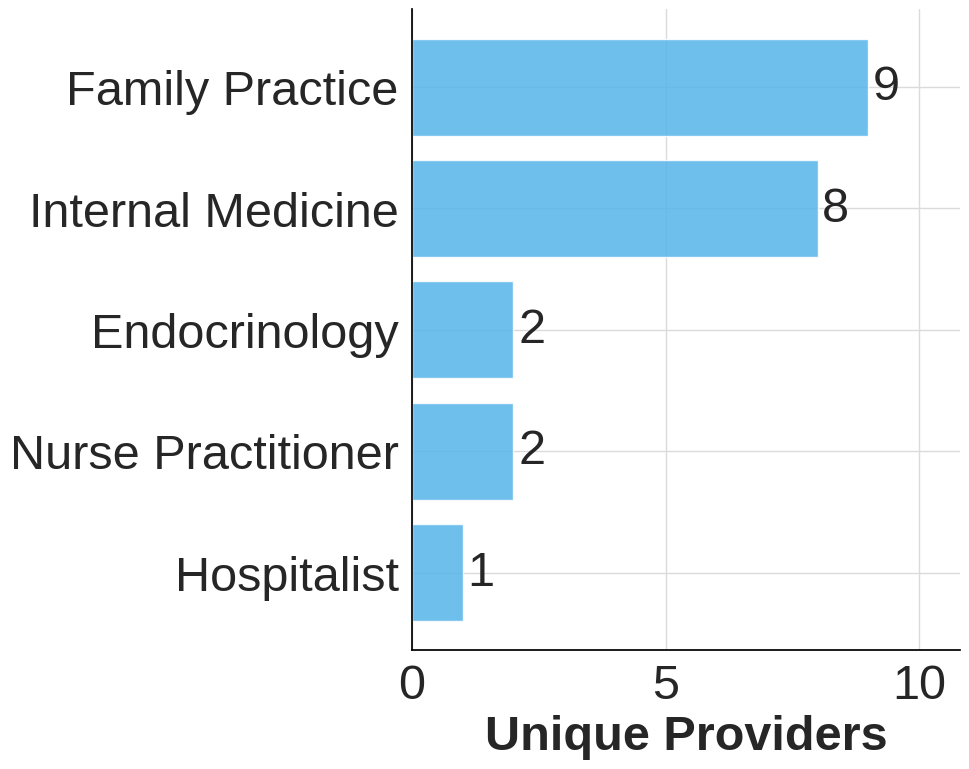

In [40]:
# =============================================================================
# TOP 5 SPECIALTIES BY FRAUD FLAGS
# =============================================================================
import matplotlib.pyplot as plt

# Define the global font size
FS = 35

# Prepare the data
plot_data = (
    specialty_fraud_tbl.head(5)
    .set_index("specialty_clean")["targets"]
    .sort_values(ascending=True)
)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot using the same blue color and alpha as your DME charts
ax.barh(plot_data.index, plot_data.values, 
        color="#56B4E9", edgecolor='white', alpha=0.85)

# Formatting
# ax.set_title("Top 5 Specialties", fontsize=FS, pad=40)
ax.set_xlabel("Unique Providers", fontsize=FS)
ax.tick_params(axis='both', labelsize=FS)

# Add value annotations next to the bars (similar to the DME code)
for i, val in enumerate(plot_data.values):
    ax.text(val + plot_data.max() * 0.01, i, 
            f'{int(val):,}', 
            va='center', 
            fontsize=FS)

# Expand x-axis limit to accommodate the large font labels
ax.set_xlim(0, plot_data.max() * 1.2)

plt.tight_layout()
plt.show()

In [ ]:
df["specialty_clean"].nunique()

In [ ]:
#############################################################################==
# FRAUD BREAKDOWNS BY YEAR AND STATE
#############################################################################==
# Fraud counts by year
fraud_by_year = df.groupby("year")["target"].agg(["count", "sum"])
# Rename columns
fraud_by_year = fraud_by_year.rename(columns={"count": "total", "sum": "targets"})
# Compute fraud rate
fraud_by_year["fraud_rate"] = fraud_by_year["targets"] / fraud_by_year["total"]
# Display table
display(fraud_by_year.sort_index())

# Plot fraud rate by year
plt.figure(figsize=(10, 4))
fraud_by_year["fraud_rate"].plot(kind="bar")
plt.title("Fraud Rate by Year")
plt.xlabel("year")
plt.ylabel("fraud rate")
plt.tight_layout()
plt.show()

# Fraud counts by state; show top 25 by total volume
if "rfrg_prvdr_state_abrvtn" in df.columns:
    # Aggregate fraud by state
    fraud_by_state = df.groupby("rfrg_prvdr_state_abrvtn")["target"].agg(["count", "sum"])
    # Rename columns
    fraud_by_state = fraud_by_state.rename(columns={"count": "total", "sum": "targets"})
    # Compute fraud rate
    fraud_by_state["fraud_rate"] = fraud_by_state["targets"] / fraud_by_state["total"]
    # Sort by total volume
    fraud_by_state_top = fraud_by_state.sort_values("total", ascending=False).head(25)
    # Display table
    display(fraud_by_state_top)

    # Plot fraud flags by state
    plt.figure(figsize=(10, 6))
    fraud_by_state_top["targets"].sort_values().plot(kind="barh")
    plt.title("Top 25 States by Fraud Flags")
    plt.xlabel("fraud flag count")
    plt.tight_layout()
    plt.show()

    # Plot fraud rate by state
    plt.figure(figsize=(10, 6))
    fraud_by_state_top["fraud_rate"].sort_values().plot(kind="barh")
    plt.title("Top 25 States by Fraud Rate (Top 25 by Volume)")
    plt.xlabel("fraud rate")
    plt.tight_layout()
    plt.show()


## Clustering EDA

In [ ]:
#############################################################################==
# PCA ANALYSIS - VARIANCE EXPLAINED AND FRAUD VISUALIZATION
#############################################################################==
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Identify numeric columns for PCA (exclude identifiers and target)
exclude_cols = ['npi', 'rfrg_prvdr_state_abrvtn', 'year', 'target', 'target',
                'og_specialty_name', 'first_payment_date', 'last_payment_date',
                'specialty_type', 'specialty']

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f"Number of features for PCA: {len(feature_cols)}")

# Prepare data - drop rows with missing values for PCA
df_pca = df[feature_cols + ['target']].dropna()
X = df_pca[feature_cols].values
y = df_pca['target'].values

print(f"Samples after dropping NaN: {len(X):,}")
print(f"Fraud cases: {y.sum():,} ({100*y.mean():.4f}%)")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Cumulative variance explained
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative_var >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {n_components} components")


In [ ]:
#############################################################################==
# PCA - SCREE PLOT AND CUMULATIVE VARIANCE
#############################################################################==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (top 50 components)
n_show = min(50, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show], 
            color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot (Top 50 Components)')

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-', linewidth=2)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].set_xlim([0, min(100, len(cumulative_var))])

plt.tight_layout()
plt.show()

# Top contributing features to first 2 PCs
print("\nTop 10 features contributing to PC1:")
pc1_loadings = pd.Series(pca_full.components_[0], index=feature_cols)
print(pc1_loadings.abs().nlargest(10))

print("\nTop 10 features contributing to PC2:")
pc2_loadings = pd.Series(pca_full.components_[1], index=feature_cols)
print(pc2_loadings.abs().nlargest(10))


In [ ]:
# =============================================================================
# UMAP VISUALIZATION - FRAUD VS NON-FRAUD CLUSTERS
# =============================================================================
import umap

print(f"Running UMAP on full dataset: {len(X_scaled):,} samples (fraud: {y.sum():,})")

# Fit UMAP on entire dataset
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, 
                    metric='euclidean', random_state=42, n_jobs=-1)
embedding_umap = reducer.fit_transform(X_scaled)

# Plot UMAP
fig, ax = plt.subplots(figsize=(12, 8))

# Plot non-fraud first (background)
mask_non_fraud = y == 0
ax.scatter(embedding_umap[mask_non_fraud, 0], embedding_umap[mask_non_fraud, 1],
           c='steelblue', alpha=0.3, s=10, label='Non-Fraud')

# Plot fraud on top (foreground)
mask_fraud = y == 1
ax.scatter(embedding_umap[mask_fraud, 0], embedding_umap[mask_fraud, 1],
           c='red', alpha=0.8, s=50, label='Fraud', edgecolors='black', linewidths=0.5)

ax.set_title('UMAP Projection: Fraud vs Non-Fraud (Full Dataset)', fontsize=14)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# t-SNE VISUALIZATION - FRAUD VS NON-FRAUD CLUSTERS
# =============================================================================
from sklearn.manifold import TSNE

print(f"Running t-SNE on full dataset: {len(X_scaled):,} samples (fraud: {y.sum():,})")

# First reduce dimensionality with PCA (recommended for t-SNE)
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_scaled)
print(f"Variance explained by 50 PCA components: {pca_50.explained_variance_ratio_.sum():.2%}")

# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', 
            init='pca', random_state=42, n_jobs=-1)
embedding_tsne = tsne.fit_transform(X_pca_50)

# Plot t-SNE
fig, ax = plt.subplots(figsize=(12, 8))

# Plot non-fraud first (background)
mask_non_fraud = y == 0
ax.scatter(embedding_tsne[mask_non_fraud, 0], embedding_tsne[mask_non_fraud, 1],
           c='steelblue', alpha=0.3, s=10, label='Non-Fraud')

# Plot fraud on top (foreground)
mask_fraud = y == 1
ax.scatter(embedding_tsne[mask_fraud, 0], embedding_tsne[mask_fraud, 1],
           c='red', alpha=0.8, s=50, label='Fraud', edgecolors='black', linewidths=0.5)

ax.set_title('t-SNE Projection: Fraud vs Non-Fraud (Full Dataset)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.show()